In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
from torch.utils.data import DataLoader 
from PIL import Image
from matplotlib import pyplot as plt
import seaborn as sns
import wandb
import math
import argparse
import datetime
import math
from time import time
from scipy import stats


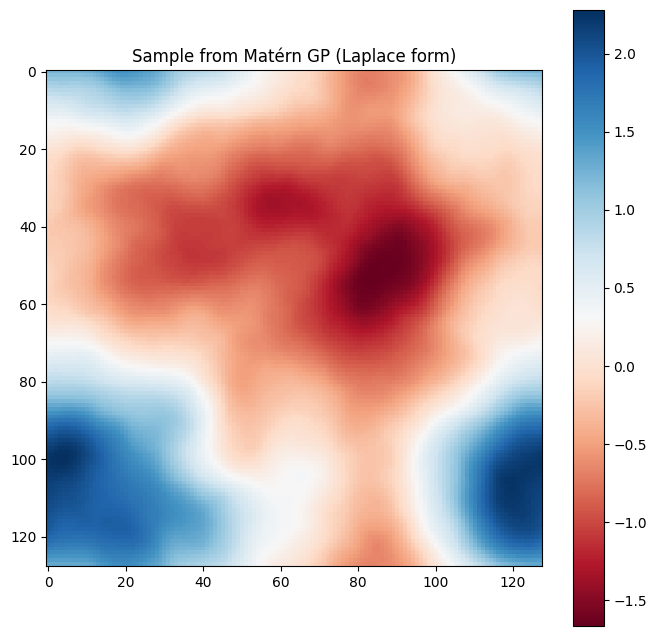

tensor(0.7558)

In [2]:
def generate_matern_laplace(num_samples, grid_size, sigma_sq, length_scale, s, seed=None):
    """
    Generate Matérn GP using the operator form σ²(-Δ + l²I)^{-s}
    We are sampling a 0 mean GRF on a 2d grid. The fourier spectrum of the domain is s(k) above.

    
    Args:
        grid_size (int): Size of the grid (N x N)
        sigma_sq (float): Variance parameter σ²
        length_scale (float): Length scale l
        s (float): Smoothness parameter s
        seed (int): Random seed for reproducibility
    
    Returns:
        torch.Tensor: Sample from the GP
    """
    if seed is not None:
        torch.manual_seed(seed)
    
    # Generate frequency grid (scaled by 2π)
    freq = torch.fft.fftfreq(grid_size) * grid_size # removed the 2pi - unit consistency??
    freq_x, freq_y = torch.meshgrid(freq, freq, indexing='ij')
    
    # Compute -Laplacian in Fourier space: |k|²
    laplacian = freq_x**2 + freq_y**2
    
    # Compute spectral density: σ²(|k|² + l²)^{-s}
    spectral_density = sigma_sq * (laplacian + (length_scale**2))**(-s)
    spectral_density[0,0]= 0
    spectral_density = spectral_density.unsqueeze(0)  # adding 1 dim
    
    
    # Generate complex Gaussian noise
    noise_real = torch.randn(num_samples, grid_size, grid_size)
    noise_imag = torch.randn(num_samples, grid_size, grid_size)
    noise = noise_real + 1j * noise_imag
    
    # Apply sqrt of spectral density
    spectral_sample = torch.sqrt(spectral_density) * noise
    
    # Transform back to spatial domain
    sample = torch.fft.ifft2(spectral_sample, norm='forward')
    sample = sample.real
    
    return sample


def plot_sample(sample):
    """Plot a sample from the GP"""
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(8, 8))
    plt.imshow(sample.numpy(), cmap='RdBu')
    plt.colorbar()
    plt.title('Sample from Matérn GP (Laplace form)')
    plt.show()

# Example usage

grid_size = 128
sample = generate_matern_laplace(
    num_samples=1000,
    grid_size=grid_size,
    sigma_sq=1,
    length_scale=1.0,
    s=3,
    seed=42
)

# Plot the sample
plot_sample(sample[0,...])
# (sample[:,...]**2).mean()

spatial_variance = (sample**2).mean(dim=(1, 2))
spatial_variance.mean()

In [3]:
def get_Fourier_spectrum(data):
    """Radially-averaged power spectrum. data: (B,N,N) torch."""
    data_hat = torch.fft.fftn(data, dim=(1, 2), norm="forward")
    fourier_amplitudes = (data_hat.abs() ** 2).mean(dim=0)  # (N,N)

    npix = data.shape[-1]
    kfreq = np.fft.fftfreq(npix) * npix
    kx, ky = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kx**2 + ky**2).reshape(-1)

    amps = fourier_amplitudes.detach().cpu().numpy().reshape(-1)

    kbins = np.arange(0.5, npix // 2 + 1, 1.0)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])

    Abins, _, _ = stats.binned_statistic(knrm, amps, statistic="mean", bins=kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)  # area weighting
    return kvals, Abins

In [4]:
def make_knrm_grid(grid_size: int, device=None):
    freq = torch.fft.fftfreq(grid_size, device=device) * grid_size
    kx, ky = torch.meshgrid(freq, freq, indexing="ij")
    knrm = torch.sqrt(kx**2 + ky**2)
    return knrm  # (N, N)

def make_radial_band_mask(grid_size: int, k_lo: float, k_hi: float, device=None, dtype=torch.float32):
    knrm = make_knrm_grid(grid_size, device=device)
    mask = ((knrm >= k_lo) & (knrm < k_hi)).to(dtype)
    return mask  # (N, N)

In [ ]:
def radial_bandpass(x: torch.Tensor, mask: torch.Tensor, norm="forward"):
    # x: (..., N, N), mask: (N, N) on same device
    X = torch.fft.fft2(x, dim=(-2, -1), norm=norm)
    Xf = X * mask  # broadcast over batch dims
    xf = torch.fft.ifft2(Xf, dim=(-2, -1), norm=norm).real
    return xf

In [8]:
def generate_multiband_dataset_postmask(
    num_samples: int,
    grid_size: int,
    components: list[dict],   # each: {name, sigma_sq, kappa/length_scale, s, band=(lo,hi)}
    weights: list[float] | None = None,
    seed: int | None = None,
    normalize: bool = True,
    device=None,
):
    device = device or "cpu"
    if weights is None:
        weights = [1.0] * len(components)
    assert len(weights) == len(components)

    xs, ffts, used_bands = {}, {}, {}

    for j, comp in enumerate(components):
        name = comp.get("name", f"comp{j}")
        comp_seed = None if seed is None else seed + 10_000 * j

        # generate broadband Matérn component (your function, unchanged)
        xj = generate_matern_laplace(
            num_samples=num_samples,
            grid_size=grid_size,
            sigma_sq=comp.get("sigma_sq", 1.0),
            length_scale=comp.get("kappa", comp.get("length_scale", 1.0)),  # supports either key
            s=comp.get("s", 2.0),
            seed=comp_seed,
        ).to(device)

        # bandpass
        band = comp.get("band", None)
        if band is not None:
            k_lo, k_hi = band
            mask = make_radial_band_mask(grid_size, k_lo, k_hi, device=device, dtype=xj.dtype)
            xj = radial_bandpass(xj, mask)
            used_bands[name] = band

            frac_in = band_power_fraction(xj, mask)  # xj is already bandpassed
            print(f"[{name}] mean frac in-band: {frac_in.mean().item():.6f} | "
            f"mean leakage: {(1-frac_in).mean().item():.6f} | "
            f"worst leakage: {(1-frac_in).max().item():.6f}")
        xs[name] = xj
        ffts[name] = torch.fft.fft2(xj, dim=(-2, -1))

    x = sum(w * xs[components[i].get("name", f"comp{i}")] for i, w in enumerate(weights))
    X = torch.fft.fft2(x, dim=(-2, -1))

    normalization = None
    if normalize:
        mean = x.mean()
        std = x.std().clamp_min(1e-8)
        x = (x - mean) / std
        normalization = {"mean": mean.item(), "std": std.item()}

    return {
        "combined": x,
        "components": xs,
        "component_ffts": ffts,
        "combined_fft": X,
        "bands": used_bands,
        "normalization": normalization,
        "grid_size": grid_size,
    }


In [11]:
import torch

@torch.no_grad()
def band_power_fraction(x: torch.Tensor, mask: torch.Tensor, norm=None, eps=1e-12):
    """
    x: (..., N, N) real
    mask: (N, N) float/bool on same device, 1 inside band
    returns: frac_in: (...) fraction of total Fourier power inside mask
    """

    X = torch.fft.fft2(x, dim=(-2, -1), norm=norm)
    P = (X.real**2 + X.imag**2)  # |X|^2, shape (..., N, N)

    # broadcast mask over leading dims
    P_in = (P * mask).sum(dim=(-2, -1))
    P_tot = P.sum(dim=(-2, -1)).clamp_min(eps)

    frac_in = P_in / P_tot
    return frac_in  # one value per sample (or per leading batch element)


In [13]:
components = [
    {"name": "coarse",    "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",      "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",      "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",      "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]

result = generate_multiband_dataset_postmask(
    num_samples=30,
    grid_size=128,
    components=components,
    weights=[1.0, 0.8, 0.8, 1.2],  # boost fine if you want
    seed=42,
    normalize=True,
)

[coarse] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid1] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid2] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[fine] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000


In [14]:
# --- simple dataset stats ---
def print_dataset_stats(x, name="data"):
    # x: (B,N,N)
    x_flat = x.view(x.shape[0], -1)
    print(f"\n=== {name} stats ===")
    print(f"shape: {tuple(x.shape)}")
    print(f"global mean/std: {x.mean().item():.4f} / {x.std().item():.4f}")
    print(f"global min/max: {x.min().item():.4f} / {x.max().item():.4f}")
    print(f"per-sample mean: mean={x_flat.mean(1).mean().item():.4f}, std={x_flat.mean(1).std().item():.4f}")
    print(f"per-sample std : mean={x_flat.std(1).mean().item():.4f}, std={x_flat.std(1).std().item():.4f}")


# --- plotting helpers ---
def plot_components(result, sample_idx=0):
    comps = result["components"]          # dict name -> (B,N,N)
    combined = result["combined"]         # (B,N,N)

    names = list(comps.keys()) + ["combined"]
    tensors = [comps[k] for k in comps.keys()] + [combined]

    n = len(tensors)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2))
    if n == 1:
        axes = [axes]

    for ax, name, t in zip(axes, names, tensors):
        img = t[sample_idx].detach().cpu().numpy()
        ax.imshow(img, origin="lower")
        ax.set_title(name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_spectra(result):
    comps = result["components"]
    combined = result["combined"]

    plt.figure(figsize=(7, 5))
    for name, x in comps.items():
        k, P = get_Fourier_spectrum(x)
        plt.plot(k, P, label=name)

    k, P = get_Fourier_spectrum(combined)
    plt.plot(k, P, label="combined", linewidth=2)

    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("k (index wavenumber)")
    plt.ylabel("radial power")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
def verify_fft_decomposition(result, weights):
    # assumes result["combined"] was formed as sum_i w_i * component_i WITHOUT normalization
    comps_fft = result["component_ffts"]  # dict name -> FFT(B,N,N)
    combined_fft = result["combined_fft"]
    names = list(result["components"].keys())
    assert len(names) == len(weights)

    recon = sum(w * comps_fft[name] for w, name in zip(weights, names))
    err = (recon - combined_fft).abs().mean().item()
    print(f"\n=== Fourier decomposition check (normalize=False only) ===")
    print(f"Mean |recon_fft - combined_fft|: {err:.2e}")

[coarse] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid1] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid2] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[fine] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[coarse] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid1] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid2] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[fine] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000


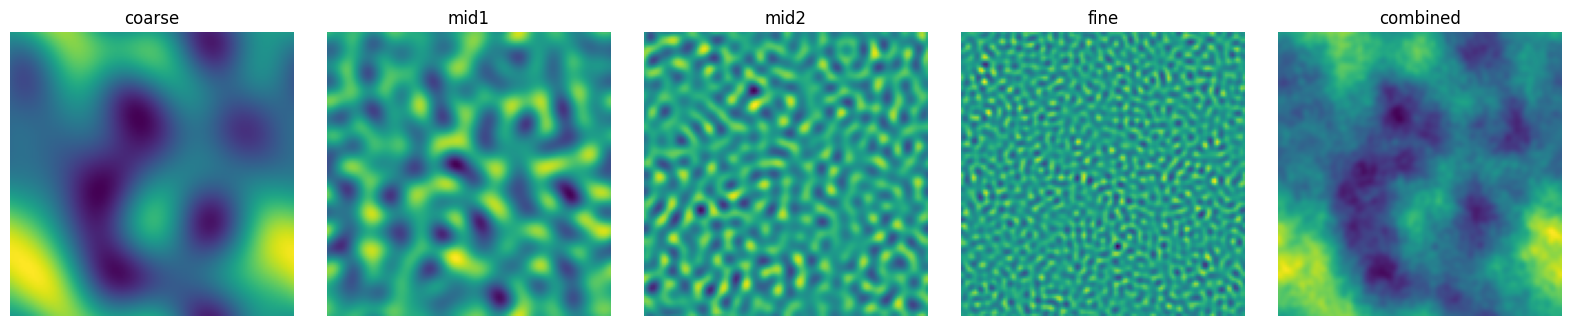

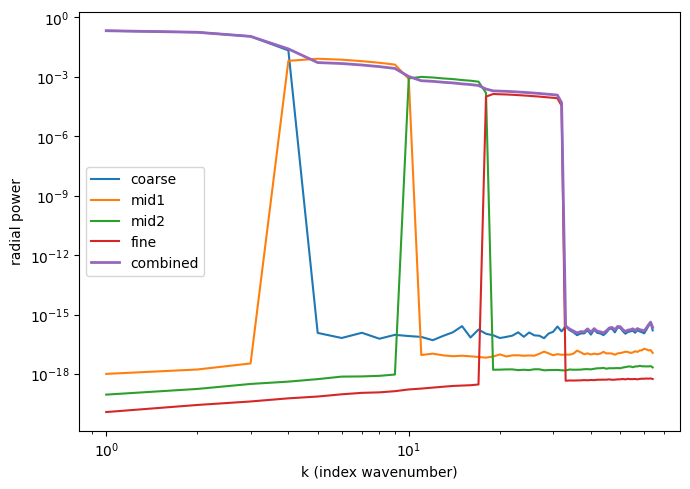


=== coarse stats ===
shape: (200, 128, 128)
global mean/std: 0.0000 / 0.7435
global min/max: -2.9442 / 3.1613
per-sample mean: mean=0.0000, std=0.0000
per-sample std : mean=0.7371, std=0.0980

=== mid1 stats ===
shape: (200, 128, 128)
global mean/std: -0.0000 / 0.1974
global min/max: -0.8450 / 0.8373
per-sample mean: mean=-0.0000, std=0.0000
per-sample std : mean=0.1972, std=0.0093

=== mid2 stats ===
shape: (200, 128, 128)
global mean/std: -0.0000 / 0.0793
global min/max: -0.4203 / 0.4178
per-sample mean: mean=-0.0000, std=0.0000
per-sample std : mean=0.0793, std=0.0022

=== fine stats ===
shape: (200, 128, 128)
global mean/std: -0.0000 / 0.0392
global min/max: -0.2066 / 0.2126
per-sample mean: mean=-0.0000, std=0.0000
per-sample std : mean=0.0392, std=0.0006

=== combined stats ===
shape: (200, 128, 128)
global mean/std: -0.0000 / 0.7642
global min/max: -3.0656 / 3.2054
per-sample mean: mean=-0.0000, std=0.0000
per-sample std : mean=0.7583, std=0.0953

=== Fourier decomposition chec

In [16]:
grid_size = 128
seed = 42

components = [
    {"name": "coarse",    "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",      "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",      "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",      "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]

weights = [1.0, 0.8, 0.8, 1.2]

# Make a SMALL TRAIN set (normalized) for your SDE/memorization experiment
train_result = generate_multiband_dataset_postmask(
    num_samples=30,
    grid_size=grid_size,
    components=components,
    weights=weights,
    seed=seed,
    normalize=True,
)


viz_result = generate_multiband_dataset_postmask(
    num_samples=200,
    grid_size=grid_size,
    components=components,
    weights=weights,
    seed=seed,
    normalize=False,
)

# Plot 1 sample of each component + combined
plot_components(viz_result, sample_idx=0)

# Plot radial spectra
plot_spectra(viz_result)

# Dataset statistics (components + combined)
for name, x in viz_result["components"].items():
    print_dataset_stats(x, name=name)
print_dataset_stats(viz_result["combined"], name="combined")

# Optional: Fourier decomposition check (only valid because normalize=False here)
verify_fft_decomposition(viz_result, weights)

In [17]:
@torch.no_grad()
def check_fft_matches_combined(batch, norm=None, eps=1e-12):
    x = batch["combined"]          # what you return (maybe normalized)
    X_stored = batch["combined_fft"]  # what you stored

    X_recomputed = torch.fft.fft2(x, dim=(-2, -1), norm=norm)

    abs_err = (X_recomputed - X_stored).abs().mean().item()
    rel_err = abs_err / (X_recomputed.abs().mean().clamp_min(eps).item())

    print("mean |fft2(combined) - combined_fft|:", abs_err)
    print("relative mean error:", rel_err)

    return abs_err, rel_err


In [18]:
@torch.no_grad()
def check_ifft_reconstructs_combined(batch, norm=None, eps=1e-12):
    x = batch["combined"]
    X_stored = batch["combined_fft"]

    x_from_fft = torch.fft.ifft2(X_stored, dim=(-2, -1), norm=norm).real

    abs_err = (x_from_fft - x).abs().mean().item()
    rel_err = abs_err / (x.abs().mean().clamp_min(eps).item())

    print("mean |ifft2(combined_fft) - combined|:", abs_err)
    print("relative mean error:", rel_err)

    return abs_err, rel_err


In [17]:
batch = generate_multiband_dataset_postmask(
    num_samples=200,
    grid_size=128,
    components=components,   # must already exist in your notebook
    weights=weights,         # or None
    seed=0,
    normalize=False,          # try True then False
         # e.g. "cuda" or "cpu"
)

# 3) Run the check
abs_err, rel_err = check_fft_matches_combined(batch)

[coarse] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid1] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid2] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[fine] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
mean |fft2(combined) - combined_fft|: 0.0
relative mean error: 0.0


In [18]:
import math
import torch

def create_fine_prominent_dataset(coarse, mid1, mid2, fine, normalize=True, eps=1e-8):
    """
    Make fine scales more prominent while keeping hierarchy.
    Target power split:
      coarse=40%, mid1=25%, mid2=20%, fine=15%
    Assumes torch tensors (e.g., shape (B,H,W) or (H,W)).
    """

    target_power = {
        "coarse": 0.40,
        "mid1": 0.25,
        "mid2": 0.20,
        "fine": 0.15,
    }

    def _std_normalize(x):
        x = x - x.mean()
        return x / x.std().clamp_min(eps)

    coarse_norm = _std_normalize(coarse) * math.sqrt(target_power["coarse"])
    mid1_norm   = _std_normalize(mid1)   * math.sqrt(target_power["mid1"])
    mid2_norm   = _std_normalize(mid2)   * math.sqrt(target_power["mid2"])
    fine_norm   = _std_normalize(fine)   * math.sqrt(target_power["fine"])

    combined = coarse_norm + mid1_norm + mid2_norm + fine_norm

    if normalize:
        combined = (combined - combined.mean()) / combined.std().clamp_min(eps)

    return combined, coarse_norm, mid1_norm, mid2_norm, fine_norm


In [ ]:

quick_balanced_weights = [0.50, 1.10, 1.80, 3.50]

result = generate_multiband_dataset_postmask(
    num_samples=200,
    grid_size=128,
    components=components,
    weights=quick_balanced_weights,  # <-- Use these
    seed=42,
    normalize=True,
)


[coarse] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid1] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid2] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[fine] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000


[coarse] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid1] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[mid2] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000
[fine] mean frac in-band: 1.000000 | mean leakage: 0.000000 | worst leakage: 0.000000


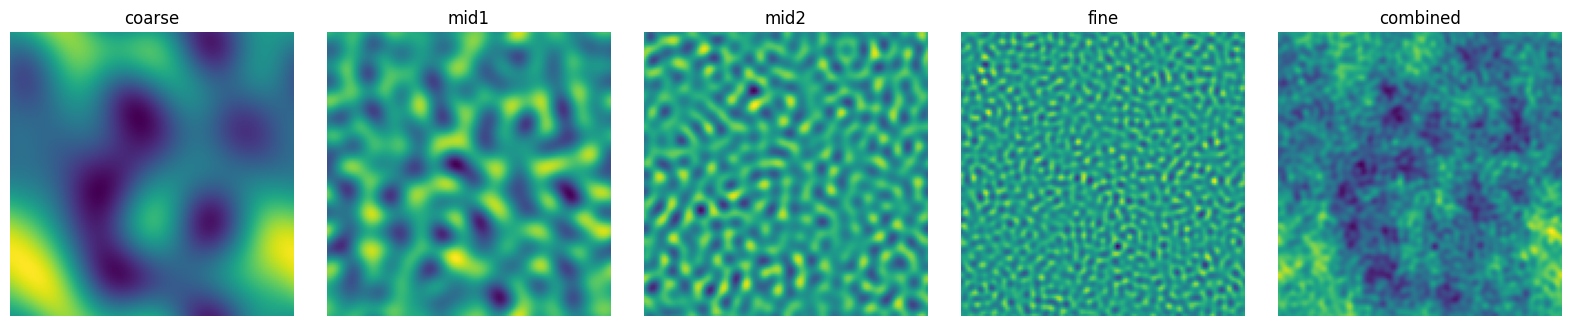

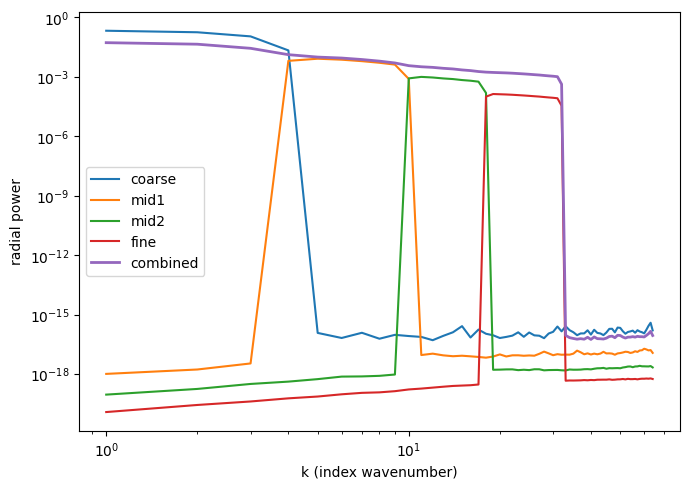


=== coarse stats ===
shape: (200, 128, 128)
global mean/std: 0.0000 / 0.7435
global min/max: -2.9442 / 3.1613
per-sample mean: mean=0.0000, std=0.0000
per-sample std : mean=0.7371, std=0.0980

=== mid1 stats ===
shape: (200, 128, 128)
global mean/std: -0.0000 / 0.1974
global min/max: -0.8450 / 0.8373
per-sample mean: mean=-0.0000, std=0.0000
per-sample std : mean=0.1972, std=0.0093

=== mid2 stats ===
shape: (200, 128, 128)
global mean/std: -0.0000 / 0.0793
global min/max: -0.4203 / 0.4178
per-sample mean: mean=-0.0000, std=0.0000
per-sample std : mean=0.0793, std=0.0022

=== fine stats ===
shape: (200, 128, 128)
global mean/std: -0.0000 / 0.0392
global min/max: -0.2066 / 0.2126
per-sample mean: mean=-0.0000, std=0.0000
per-sample std : mean=0.0392, std=0.0006

=== combined stats ===
shape: (200, 128, 128)
global mean/std: -0.0000 / 0.4739
global min/max: -2.2100 / 2.3194
per-sample mean: mean=-0.0000, std=0.0000
per-sample std : mean=0.4724, std=0.0387

=== Fourier decomposition chec

In [21]:
viz2_result = generate_multiband_dataset_postmask(
    num_samples=200,
    grid_size=grid_size,
    components=components,
    weights=quick_balanced_weights,
    seed=seed,
    normalize=False,
)

# Plot 1 sample of each component + combined
plot_components(viz2_result, sample_idx=0)

# Plot radial spectra
plot_spectra(viz2_result)

# Dataset statistics (components + combined)
for name, x in viz2_result["components"].items():
    print_dataset_stats(x, name=name)
print_dataset_stats(viz2_result["combined"], name="combined")

# Optional: Fourier decomposition check (only valid because normalize=False here)
verify_fft_decomposition(viz2_result, quick_balanced_weights)

In [19]:

def make_radial_k_grid(N, device=None):
    k = torch.fft.fftfreq(N, d=1.0, device=device) * N  # cycles/sample * N
    kx, ky = torch.meshgrid(k, k, indexing="ij")
    return torch.sqrt(kx**2 + ky**2)  # (N,N)

def ring_mask(N, k0, width, device=None, dtype=torch.float32):
    kr = make_radial_k_grid(N, device=device)
    m = (kr >= (k0 - width/2)) & (kr <= (k0 + width/2))
    return m.to(dtype=dtype)

def band_mask(N, kmin, kmax, device=None, dtype=torch.float32):
    kr = make_radial_k_grid(N, device=device)
    m = (kr >= kmin) & (kr <= kmax)
    return m.to(dtype=dtype)

def make_bandlimited_pattern(N, mask, seed=0, device=None):
    """
    Create a REAL band-limited spatial pattern by:
      w ~ N(0,1) in space -> FFT -> keep only masked freqs -> iFFT -> normalize.
    mask: (N,N) float in {0,1} (unshifted freq layout)
    """
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    w = torch.randn(N, N, generator=g, device=device)
    W = torch.fft.fft2(w, norm="forward")
    W_f = W * mask  # band-limit in Fourier domain
    p = torch.fft.ifft2(W_f, norm="forward").real

    p = p - p.mean()
    p = p / (p.std().clamp_min(1e-8))
    return p  # (N,N) real, unit std

def bias_fourier_watermark(x, kmin=None, kmax=None, k0=None, width=None,
                           strength=0.10, seed=123):
    """
    Add a *shared* band-limited watermark to every sample.
    x: (B,N,N) real
    Choose either:
      - (kmin,kmax) band, or
      - (k0,width) ring.
    strength is in units of x std (roughly).
    """
    B, N, _ = x.shape
    device = x.device

    if (k0 is not None) and (width is not None):
        m = ring_mask(N, k0=k0, width=width, device=device)
    else:
        assert (kmin is not None) and (kmax is not None), "Provide (kmin,kmax) or (k0,width)"
        m = band_mask(N, kmin=kmin, kmax=kmax, device=device)

    p = make_bandlimited_pattern(N, m, seed=seed, device=device)  # (N,N)
    return x + strength * p.unsqueeze(0)  # broadcast

def add_bias_to_multiscale_dict(ds, target="combined",
                               bias_type="fourier_watermark",
                               fft_norm="None",
                               overwrite_target=False,
                               **kwargs):
    """
    ds: dict containing keys like 'coarse','mid1','mid2','fine','combined', etc.
    target: any key in ds to bias (commonly 'combined')
    fft_norm: must match how you compute/store FFTs elsewhere
    overwrite_target: if True, replace ds[target] with biased version (useful if training code expects 'combined')
    """
    out = dict(ds)  # shallow copy
    if target not in out:
        raise KeyError(f"Target key '{target}' not found in ds. Keys: {list(out.keys())}")

    x = out[target]

    if bias_type == "fourier_watermark":
        xb = bias_fourier_watermark(x, **kwargs)
        canary_mask = None
    else:
        raise ValueError(f"Unknown bias_type: {bias_type}")

    # store outputs
    out[f"{target}_biased"] = xb
    out[f"{target}_biased_fft"] = torch.fft.fft2(xb, dim=(-2, -1), norm=fft_norm)
    out["bias_meta"] = {"target": target, "bias_type": bias_type, "fft_norm": fft_norm, **kwargs}
    if canary_mask is not None:
        out["canary_mask"] = canary_mask

    # optionally overwrite target (often helpful for training pipelines)
    if overwrite_target:
        out[f"{target}_clean"] = x
        out[target] = xb

    return out


In [20]:
def add_fourier_bias_to_result(
    result: dict,
    kmin: float = None,
    kmax: float = None,
    k0: float = None,
    width: float = None,
    strength: float = 0.10,
    seed: int = 123,
    overwrite_combined: bool = True,
) -> dict:
    """
    Apply a band-limited Fourier watermark to result["combined"].
    Uses norm=None (backward) everywhere to match how component_ffts / combined_fft
    are stored in generate_multiband_dataset_postmask.

    Args:
        result: dict from generate_multiband_dataset_postmask
        kmin, kmax: frequency band (cycles per grid), or use k0+width for a ring
        k0, width: ring-mask alternative to kmin/kmax
        strength: bias amplitude in units of data std (~0.10 = 10%)
        seed: for reproducible pattern
        overwrite_combined: if True, result["combined"] becomes the biased version

    Returns:
        updated result dict (shallow copy)
    """
    out = dict(result)

    x = out["combined"]          # (B, N, N), already normalized
    B, N, _ = x.shape
    device = x.device

    # --- build frequency mask (same convention as make_radial_k_grid) ---
    k = torch.fft.fftfreq(N, d=1.0, device=device) * N
    kx, ky = torch.meshgrid(k, k, indexing="ij")
    kr = torch.sqrt(kx**2 + ky**2)

    if k0 is not None and width is not None:
        mask = ((kr >= k0 - width / 2) & (kr <= k0 + width / 2)).float()
    elif kmin is not None and kmax is not None:
        mask = ((kr >= kmin) & (kr <= kmax)).float()
    else:
        raise ValueError("Provide (kmin, kmax) or (k0, width)")

    # --- build band-limited pattern (norm="forward" internally, then back) ---
    # We generate in forward-norm space; result is a real spatial field → fine.
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    w = torch.randn(N, N, generator=g, device=device)
    W = torch.fft.fft2(w, norm="forward")
    W_f = W * mask
    p = torch.fft.ifft2(W_f, norm="forward").real
    p = p - p.mean()
    p = p / p.std().clamp_min(1e-8)   # (N, N), unit std

    # --- add bias ---
    x_biased = x + strength * p.unsqueeze(0)   # (B, N, N)

    # --- store outputs (use norm=None to match existing FFTs in result) ---
    out["combined_clean"]  = x
    out["combined_biased"] = x_biased
    out["combined_biased_fft"] = torch.fft.fft2(x_biased, dim=(-2, -1))  # norm=None = backward
    out["bias_pattern"]    = p          # (N, N) for inspection
    out["bias_mask"]       = mask       # (N, N) frequency mask
    out["bias_meta"]       = {
        "kmin": kmin, "kmax": kmax, "k0": k0, "width": width,
        "strength": strength, "seed": seed,
    }

    if overwrite_combined:
        out["combined"] = x_biased

    return out


# ── Example usage ──────────────────────────────────────────────────────────────
# Pick a band that doesn't overlap your 4 data bands (0.5–32) — or intentionally
# put it inside one. Here we use a narrow ring in the mid range as an example:

biased_train = add_fourier_bias_to_result(
    train_result,
    k0=8.0,        # center frequency (cycles per 128-pixel grid)
    width=2.0,     # ring width
    strength=0.10,
    seed=999,
    overwrite_combined=True,
)

# Sanity checks
p = biased_train["bias_pattern"]
print(f"Pattern mean: {p.mean():.4f}  std: {p.std():.4f}")   # ~0, ~1

diff = biased_train["combined"] - biased_train["combined_clean"]
print(f"Max diff: {diff.abs().max():.4f}  (should be 0.10 * pattern_range)")

# Verify the bias lives in the right frequency band
X_diff = torch.fft.fft2(diff, dim=(-2, -1))
P_diff = (X_diff.abs()**2).mean(0)   # mean power over samples
mask = biased_train["bias_mask"]
frac_in = (P_diff * mask).sum() / P_diff.sum()
print(f"Fraction of bias power in target band: {frac_in:.6f}")  # should be ~1.0

Pattern mean: 0.0000  std: 1.0000
Max diff: 0.3399  (should be 0.10 * pattern_range)
Fraction of bias power in target band: 1.000000


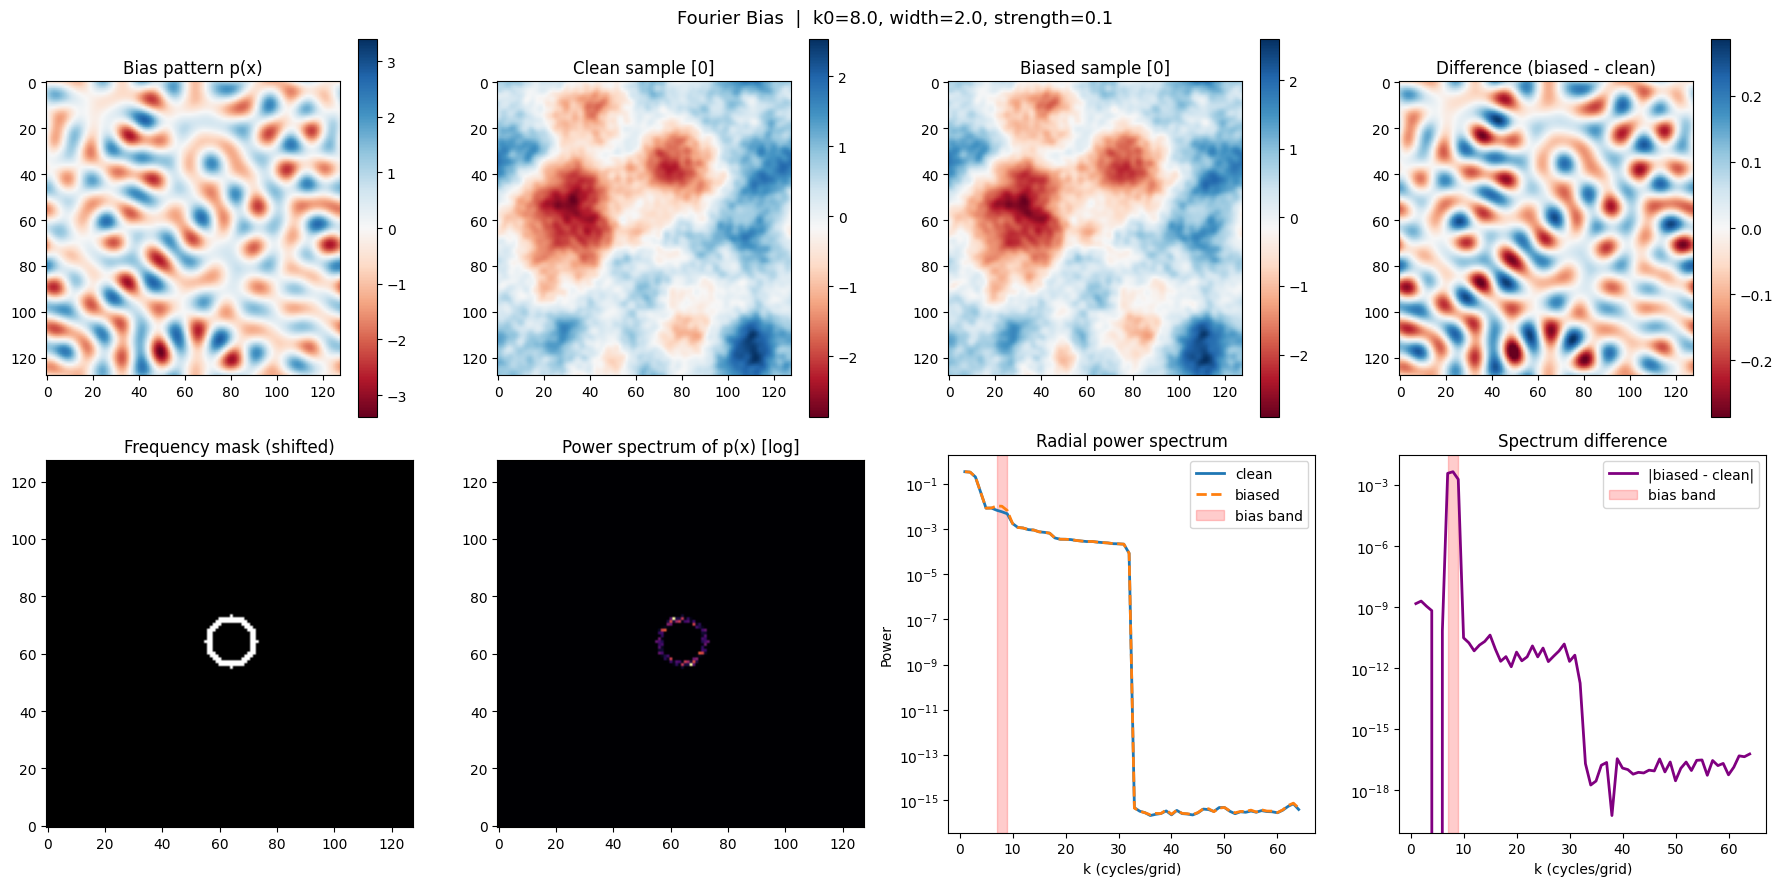

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_bias(biased_result):
    p       = biased_result["bias_pattern"]          # (N, N)
    mask    = biased_result["bias_mask"]             # (N, N)
    clean   = biased_result["combined_clean"]        # (B, N, N)
    biased  = biased_result["combined"]              # (B, N, N)
    meta    = biased_result["bias_meta"]

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f"Fourier Bias  |  k0={meta['k0']}, width={meta['width']}, strength={meta['strength']}", fontsize=13)

    # --- Row 1: spatial ---
    vmax = p.abs().max().item()
    im0 = axes[0, 0].imshow(p.cpu().numpy(), cmap="RdBu", vmin=-vmax, vmax=vmax)
    axes[0, 0].set_title("Bias pattern p(x)")
    plt.colorbar(im0, ax=axes[0, 0])

    im1 = axes[0, 1].imshow(clean[0].cpu().numpy(), cmap="RdBu")
    axes[0, 1].set_title("Clean sample [0]")
    plt.colorbar(im1, ax=axes[0, 1])

    im2 = axes[0, 2].imshow(biased[0].cpu().numpy(), cmap="RdBu")
    axes[0, 2].set_title("Biased sample [0]")
    plt.colorbar(im2, ax=axes[0, 2])

    diff = (biased[0] - clean[0]).cpu().numpy()
    im3 = axes[0, 3].imshow(diff, cmap="RdBu", vmin=-diff.max(), vmax=diff.max())
    axes[0, 3].set_title("Difference (biased - clean)")
    plt.colorbar(im3, ax=axes[0, 3])

    # --- Row 2: Fourier ---
    N = p.shape[0]

    # frequency mask (fftshifted for display)
    axes[1, 0].imshow(np.fft.fftshift(mask.cpu().numpy()), cmap="gray", origin="lower")
    axes[1, 0].set_title("Frequency mask (shifted)")

    # power spectrum of bias pattern
    P_bias = torch.fft.fftshift(torch.fft.fft2(p, norm="forward").abs()**2)
    axes[1, 1].imshow(torch.log1p(P_bias).cpu().numpy(), cmap="inferno", origin="lower")
    axes[1, 1].set_title("Power spectrum of p(x) [log]")

    # radially averaged spectra: clean vs biased (mean over batch)
    def radial_spectrum(x_batch):
        X = torch.fft.fft2(x_batch, dim=(-2,-1), norm="forward")
        PA = (X.abs()**2).mean(0).cpu().numpy().reshape(-1)
        kfreq = np.fft.fftfreq(N) * N
        kx, ky = np.meshgrid(kfreq, kfreq)
        kr = np.sqrt(kx**2 + ky**2).reshape(-1)
        kbins = np.arange(0.5, N//2 + 1, 1.0)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
        from scipy import stats
        Abins, _, _ = stats.binned_statistic(kr, PA, statistic="mean", bins=kbins)
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
        return kvals, Abins

    kvals, Ac = radial_spectrum(clean)
    kvals, Ab = radial_spectrum(biased)

    ax = axes[1, 2]
    ax.semilogy(kvals, Ac, label="clean", lw=2)
    ax.semilogy(kvals, Ab, label="biased", lw=2, linestyle="--")
    # shade the target band
    if meta["k0"] is not None:
        ax.axvspan(meta["k0"] - meta["width"]/2, meta["k0"] + meta["width"]/2,
                   alpha=0.2, color="red", label="bias band")
    elif meta["kmin"] is not None:
        ax.axvspan(meta["kmin"], meta["kmax"], alpha=0.2, color="red", label="bias band")
    ax.set_xlabel("k (cycles/grid)")
    ax.set_ylabel("Power")
    ax.set_title("Radial power spectrum")
    ax.legend()

    # difference spectrum
    ax2 = axes[1, 3]
    ax2.semilogy(kvals, np.abs(Ab - Ac), label="|biased - clean|", color="purple", lw=2)
    if meta["k0"] is not None:
        ax2.axvspan(meta["k0"] - meta["width"]/2, meta["k0"] + meta["width"]/2,
                    alpha=0.2, color="red", label="bias band")
    elif meta["kmin"] is not None:
        ax2.axvspan(meta["kmin"], meta["kmax"], alpha=0.2, color="red", label="bias band")
    ax2.set_xlabel("k (cycles/grid)")
    ax2.set_title("Spectrum difference")
    ax2.legend()

    plt.tight_layout()
    plt.show()


visualize_bias(biased_train)